In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.metrics import mean_squared_error as MSE
from sklearn.tree import DecisionTreeRegressor

In [39]:
myData = pd.read_csv('Mushroom_data.csv')
myData.head(10)

,class,cap-diameter,cap-shape,cap-surface,cap-shade,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-tallness,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,location,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w
5,p,15.34,x,g,o,f,e,NaN,w,17.84,...,s,y,w,u,w,t,p,NaN,d,u
6,p,14.85,f,h,o,f,e,NaN,w,17.71,...,s,y,w,u,w,t,g,NaN,d,w
7,p,14.86,x,h,e,f,e,NaN,w,17.03,...,s,y,w,u,w,t,p,NaN,d,u
8,p,12.85,f,g,o,f,e,NaN,w,17.27,...,s,y,w,u,w,t,p,NaN,d,a
9,p,13.55,f,g,e,f,e,NaN,w,16.04,...,s,y,w,u,w,t,p,NaN,d,w


In [40]:
myData = myData.fillna('missing')
myData_encoded = pd.get_dummies(myData)
myData_encoded.head(10)

,cap-diameter,stem-tallness,stem-width,class_e,class_p,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,...,location_h,location_l,location_m,location_p,location_u,location_w,season_a,season_s,season_u,season_w
0,15.26,16.95,17.09,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,16.60,17.99,18.19,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,14.07,17.80,17.74,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,14.17,15.77,15.98,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4,14.64,16.53,17.20,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,15.34,17.84,18.79,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
6,14.85,17.71,16.89,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
7,14.86,17.03,17.44,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
8,12.85,17.27,18.69,False,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
9,13.55,16.04,16.88,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [41]:
#Split data into training and testing

X = myData_encoded.drop(['class_p', 'class_e'], axis = 1)
y = myData_encoded['class_p']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=5, stratify=y)

In [42]:
# Model 1 - Decision Tree
clf = DecisionTreeClassifier(max_depth = 100, min_samples_split = 2, random_state = 5)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=100, random_state=5)

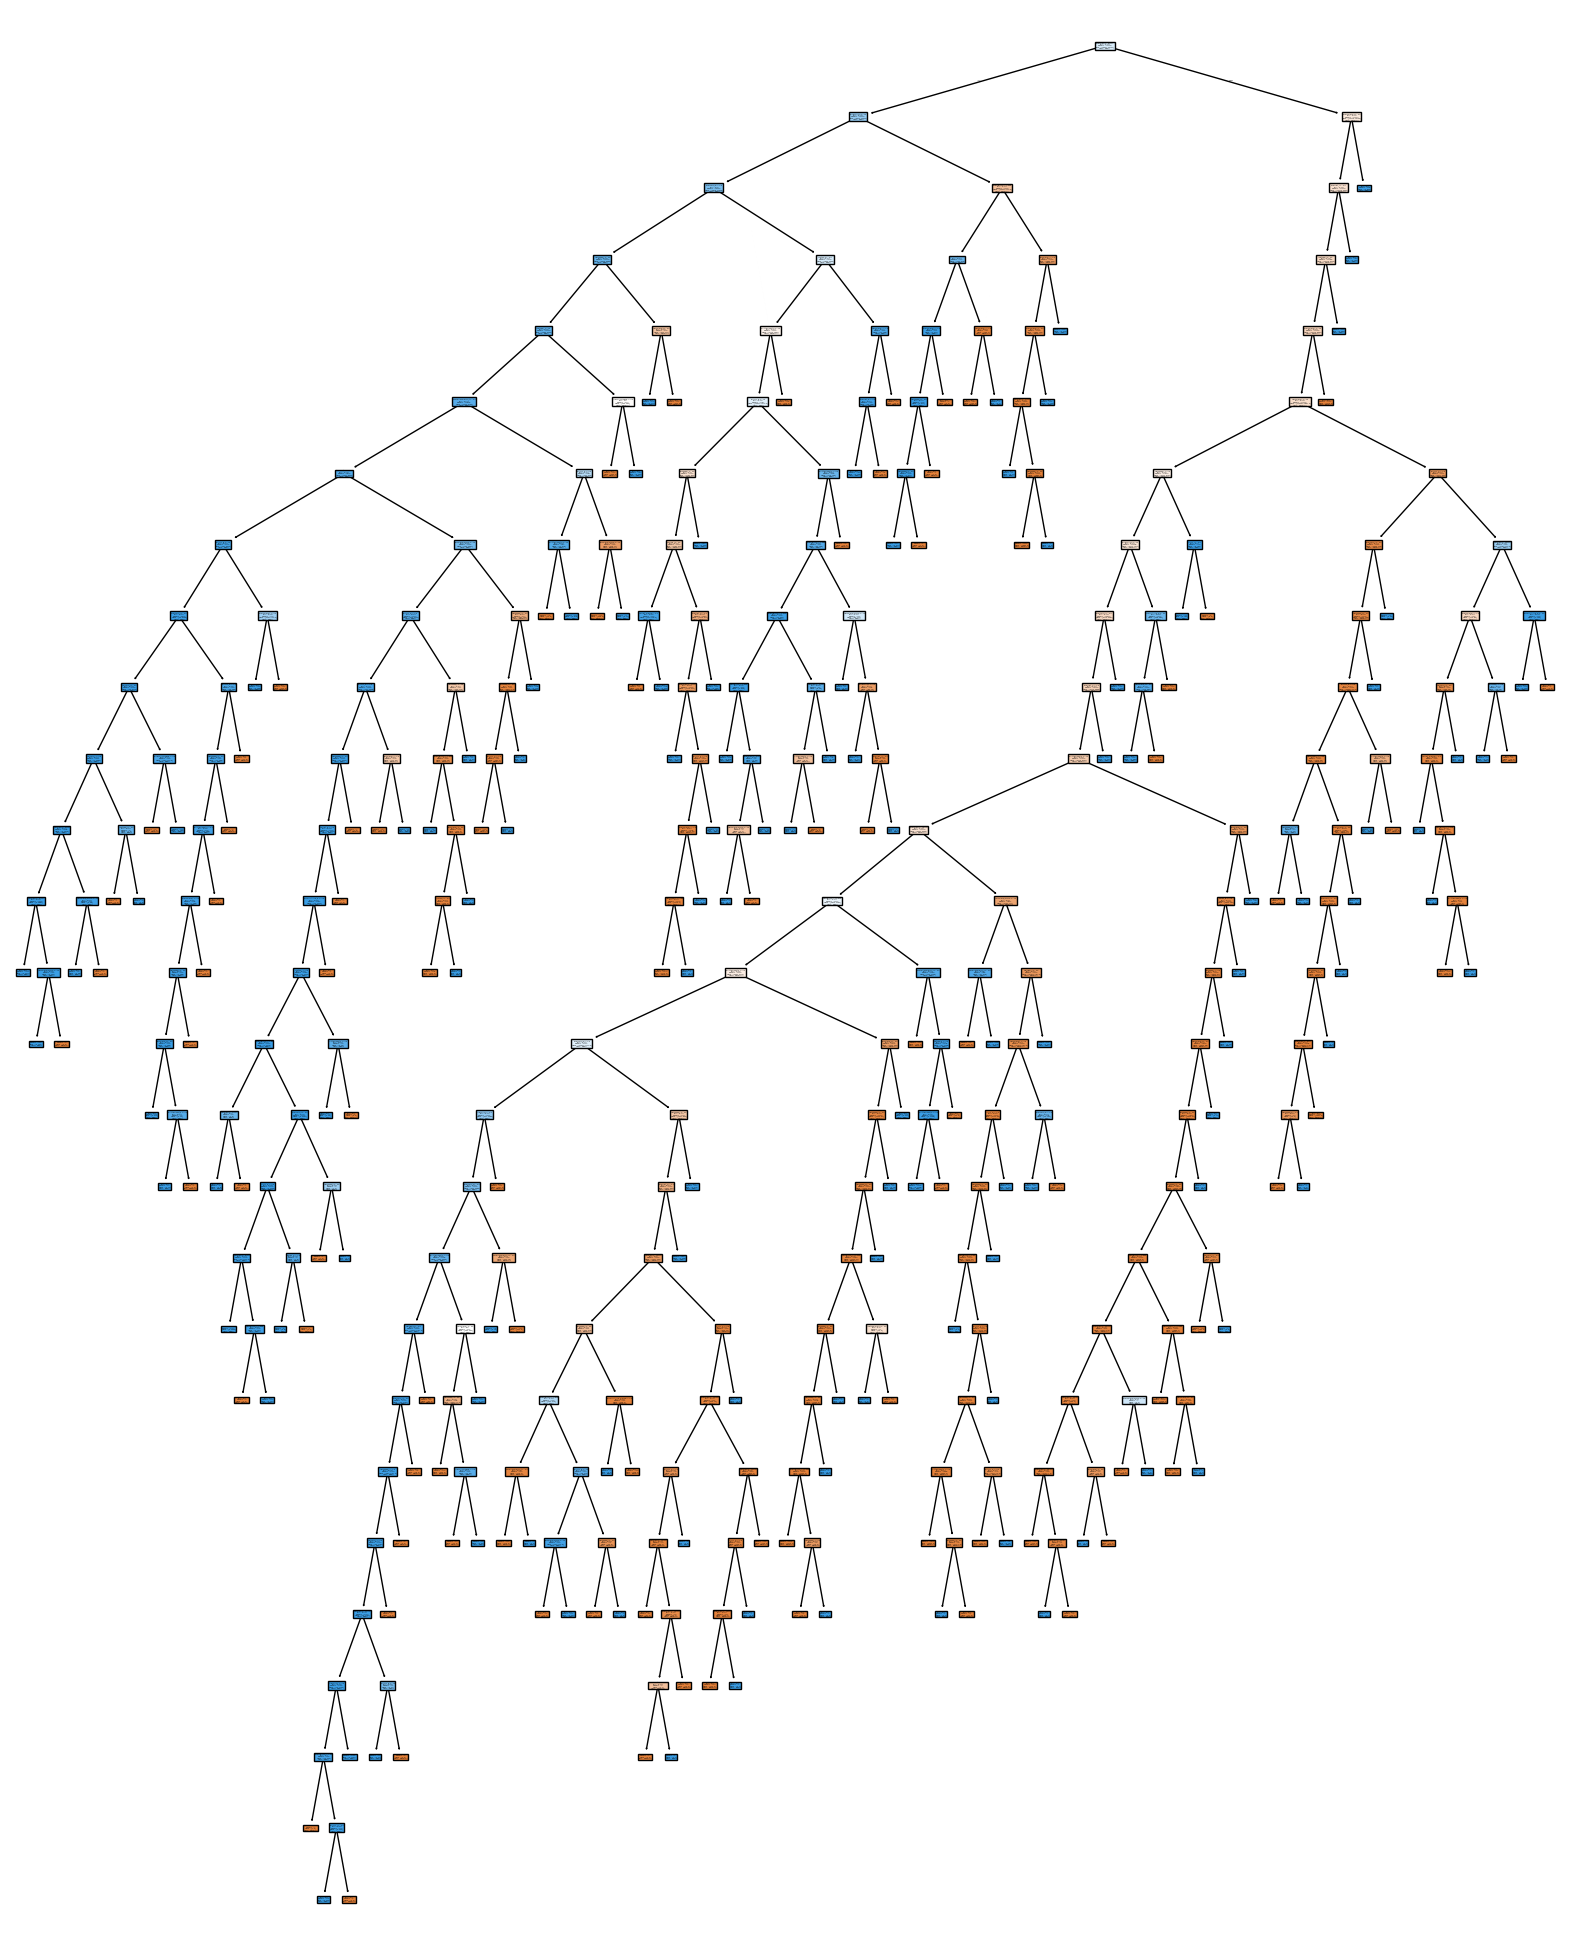

In [43]:
#Visualization of Model 1 - Decision Tree
fig = plt.figure(figsize=(20,25))
tree.plot_tree(clf, filled = True, feature_names= X_train.columns, class_names = ['poisonous', 'edible']);

In [49]:
#Model 1 accuracy score

testPredictions = clf.predict(X_test)
accuracy1 = accuracy_score(y_test, testPredictions)
print("Decision Tree Accuracy:", accuracy1)
print("Confusion Matrix")
print(confusion_matrix(y_test, testPredictions))

Decision Tree Accuracy: 0.9985808634899842
Confusion Matrix
[[ 8150     4]
 [   22 10145]]


In [50]:
#Model 2 - Random Forest

rf = RandomForestClassifier(n_estimators = 100, min_samples_split = 2, random_state=5)

rf.fit(X_train, y_train)

#Model 2 accuracy score

rfPredictions = rf.predict(X_test)
accuracy2 = accuracy_score(y_test, rfPredictions)
print("Random Forest Accuracy:", accuracy2)
print("Confusion Matrix")
print(confusion_matrix(y_test, rfPredictions))

Random Forest Accuracy: 1.0
Confusion Matrix
[[ 8154     0]
 [    0 10167]]
